# Import de bibliotecas


In [ ]:
!pip install kneed

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator
from yellowbrick.cluster import SilhouetteVisualizer
from itertools import combinations
import plotly.express as px
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from kneed import knee_locator


#Load do DF

In [2]:
import pandas as pd

# Carrega o dataset
df = pd.read_csv("dataset_processed.csv", encoding='utf-8', low_memory=True)

# Tratamento de valores faltantes

In [ ]:
# prompt: Eu quero a quantidade de valores unicos nas colunas track_name e artits do df

print(df['track_name'].nunique())
print(df['artists'].nunique())

73608
31437


In [ ]:
# 1. Mostrar quantidade total de valores nulos por coluna
print('Valores nulos por coluna:')
linhas_com_nulos = df[df.isnull().any(axis=1)]
print(linhas_com_nulos)



In [ ]:
# Remove coluna de índice automática, se existir
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Mantém apenas a primeira linha de cada track_id (uma linha por música)
df_amostrado = df.drop_duplicates(subset=['track_name', 'artists'], keep='first')


print(df_amostrado)



                      track_id                 artists  \
0       5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1       4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2       1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3       6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4       5vjLSffimiIP26QG5WcN2K        Chord Overstreet   
...                        ...                     ...   
113995  2C3TZjDRiAzdyViavDJ217           Rainy Lullaby   
113996  1hIz5L4IB9hN3WRYPOCGPw           Rainy Lullaby   
113997  6x8ZfSoqDjuNa5SVP5QjvX           Cesária Evora   
113998  2e6sXL2bYv4bSz6VTdnfLs        Michael W. Smith   
113999  2hETkH7cOfqmz3LqZDHZf5           Cesária Evora   

                                               album_name  \
0                                                  Comedy   
1                                        Ghost (Acoustic)   
2                                          To Begin Again   
3       Crazy Rich Asians (Original Motion Picture Sou...  

# Transformação de dados

In [ ]:
# Copiar o DataFrame original
df_transf = df.copy()
df_transf.head()

# Remover colunas textuais ou que não ajudam na modelagem
df_transf = df_transf.drop(columns=[
    'Unnamed: 0','track_id', 'track_name', 'album_name', 'artists', 'track_genre'
])

# Criar coluna binária: 1 se popularidade >= 60, senão 0
df_transf['is_popular'] = df_transf['popularity'].apply(lambda x: 1 if x >= 60 else 0)

df_transf = df_transf.drop(columns=['popularity'])

# Colunas categóricas para OneHotEncoder
colunas_categoricas = ['key', 'mode', 'time_signature']

# Colunas numéricas (todas exceto categóricas e target)
colunas_numericas = [col for col in df_transf.columns if col not in colunas_categoricas + ['is_popular']]

# Aplicar OneHotEncoder nas colunas categóricas com drop='first' para evitar multicolinearidade
ohe = OneHotEncoder(sparse_output=False, drop='first')
encoded_categoricas = ohe.fit_transform(df_transf[colunas_categoricas])
df_encoded = pd.DataFrame(encoded_categoricas, columns=ohe.get_feature_names_out(colunas_categoricas))

# Aplicar StandardScaler nas colunas numéricas
scaler = StandardScaler()
scaled_numericas = scaler.fit_transform(df_transf[colunas_numericas])
df_scaled = pd.DataFrame(scaled_numericas, columns=colunas_numericas)

# Concatenar tudo
X = pd.concat([df_scaled, df_encoded], axis=1)

# Target
y = df_transf['is_popular']


# Aplicação XGBoost - Márcia

Distribuição das classes após SMOTE:
is_popular
0    50756
1    50756
Name: count, dtype: int64
Matriz de Confusão (Teste - XGBoost):
[[15169  6585]
 [ 1156  1494]]


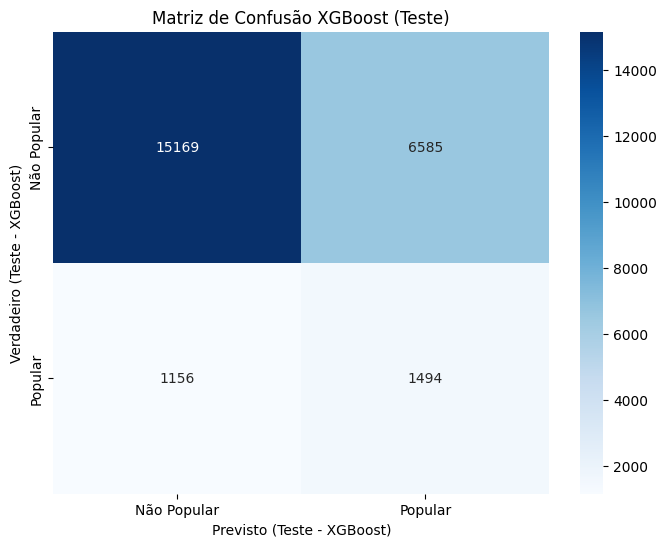


Métricas de Classificação (Teste - XGBoost):
              precision    recall  f1-score   support

 Não Popular       0.93      0.70      0.80     21754
     Popular       0.18      0.56      0.28      2650

    accuracy                           0.68     24404
   macro avg       0.56      0.63      0.54     24404
weighted avg       0.85      0.68      0.74     24404


Matriz de Confusão (Treino com SMOTE - XGBoost):
[[35994 14762]
 [ 8283 42473]]


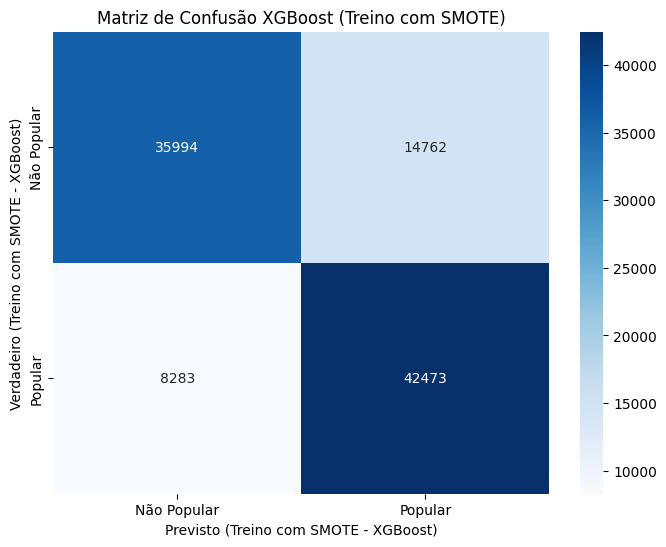


Métricas de Classificação (Treino com SMOTE - XGBoost):
              precision    recall  f1-score   support

 Não Popular       0.81      0.71      0.76     50756
     Popular       0.74      0.84      0.79     50756

    accuracy                           0.77    101512
   macro avg       0.78      0.77      0.77    101512
weighted avg       0.78      0.77      0.77    101512



In [53]:
# Importando as bibliotecas necessárias para XGBoost
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

# Usando X, y, X_train, y_train, X_test, y_test definidos em células anteriores

# Aplicar SMOTE para balancear as classes no conjunto de treino
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Converter a saída do SMOTE de volta para um DataFrame com nomes de colunas corretos
if not isinstance(X_train_bal, pd.DataFrame):
    X_train_bal = pd.DataFrame(X_train_bal, columns=X_train.columns)


print("Distribuição das classes após SMOTE:")
print(pd.Series(y_train_bal).value_counts())

# Criar DMatrix para os dados de treino e teste
if not isinstance(X_test, pd.DataFrame):
     X_test = pd.DataFrame(X_test, columns=X.columns.drop('is_popular'))


dtrain = xgb.DMatrix(X_train_bal, label=y_train_bal)
dtest = xgb.DMatrix(X_test, label=y_test)


# Definir parâmetros do XGBoost
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'eta': 0.1,
    'max_depth': 5,
    'seed': 42
}

# Número de rodadas de boosting (árvores)
num_round = 100

# Treinamento do modelo XGBoost usando xgb.train
watchlist = [(dtrain, 'train'), (dtest, 'eval')]
xgb_model = xgb.train(params, dtrain, num_round, evals=watchlist, verbose_eval=False)


# Fazendo previsões no conjunto de teste usando o booster treinado
dtest_pred = xgb.DMatrix(X_test)
y_pred_xgb_test = xgb_model.predict(dtest_pred)

# Converter previsões para binário (0 ou 1) com base em um limiar (0.5 para objetivo logístico)
y_pred_xgb_test_binary = (y_pred_xgb_test > 0.5).astype(int)


# Calculando e exibindo a matriz de confusão para o conjunto de teste
conf_matrix_xgb_test = confusion_matrix(y_test, y_pred_xgb_test_binary)
print("Matriz de Confusão (Teste - XGBoost):")
print(conf_matrix_xgb_test)

# Plotando a matriz de confusão para o conjunto de teste
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Popular', 'Popular'],
            yticklabels=['Não Popular', 'Popular'])
plt.xlabel('Previsto (Teste - XGBoost)')
plt.ylabel('Verdadeiro (Teste - XGBoost)')
plt.title('Matriz de Confusão XGBoost (Teste)')
plt.show()

# Exibindo métricas de classificação para o conjunto de teste
print("\nMétricas de Classificação (Teste - XGBoost):")
print(classification_report(y_test, y_pred_xgb_test_binary, target_names=['Não Popular', 'Popular']))

# Fazendo previsões no conjunto de treino balanceado
dtrain_pred = xgb.DMatrix(X_train_bal)
y_pred_xgb_train = xgb_model.predict(dtrain_pred)

# Converter previsões de treino para binário
y_pred_xgb_train_binary = (y_pred_xgb_train > 0.5).astype(int)


# Calculando e exibindo a matriz de confusão para o conjunto de treino balanceado
conf_matrix_xgb_train = confusion_matrix(y_train_bal, y_pred_xgb_train_binary)
print("\nMatriz de Confusão (Treino com SMOTE - XGBoost):")
print(conf_matrix_xgb_train)

# Plotando a matriz de confusão para o conjunto de treino balanceado
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Popular', 'Popular'],
            yticklabels=['Não Popular', 'Popular'])
plt.xlabel('Previsto (Treino com SMOTE - XGBoost)')
plt.ylabel('Verdadeiro (Treino com SMOTE - XGBoost)')
plt.title('Matriz de Confusão XGBoost (Treino com SMOTE)')
plt.show()

# Exibindo as métricas de classificação para o conjunto de treino balanceado com XGBoost
print("\nMétricas de Classificação (Treino com SMOTE - XGBoost):")
print(classification_report(y_train_bal, y_pred_xgb_train_binary, target_names=['Não Popular', 'Popular']))

In [50]:
# Executar a célula que prepara os dados de treino e teste e aplica SMOTE
# Remova linhas com valores nulos antes de dividir os dados
new_df = df.copy()

# Remover colunas que não contribuem para a modelagem
columns_to_drop = [
    'Unnamed: 0','track_id', 'track_name', 'album_name', 'artists', 'track_genre'
]
# Filter out columns that don't exist in df before dropping
columns_to_drop_existing = [col for col in columns_to_drop if col in new_df.columns]
new_df = new_df.drop(columns=columns_to_drop_existing, errors='ignore')


# # Criar coluna binária de popularidade
# new_df['is_popular'] = new_df['popularity'].apply(lambda x: 1 if x >= 60 else 0)

# # Remover a coluna original de popularidade (já representada por is_popular)
# new_df = new_df.drop(columns=['popularity'])

df_cleaned = new_df.dropna()

# Separar features (X) e target (y) do DataFrame limpo
colunas_categoricas_cleaned = ['key', 'mode', 'time_signature']
colunas_numericas_cleaned = [col for col in df_cleaned.columns if col not in colunas_categoricas_cleaned + ['is_popular']]

# Aplicar OneHotEncoder nas colunas categóricas do DataFrame limpo
# ohe = OneHotEncoder(sparse_output=False, drop='first')
# encoded_categoricas = ohe.fit_transform(df_cleaned[colunas_categoricas_cleaned])
# df_encoded = pd.DataFrame(encoded_categoricas, columns=ohe.get_feature_names_out(colunas_categoricas_cleaned))
df_encoded = pd.DataFrame() # Create an empty DataFrame since categorical columns are not available


# Aplicar StandardScaler nas colunas numéricas do DataFrame limpo
scaler = StandardScaler()
scaled_numericas = scaler.fit_transform(df_cleaned[colunas_numericas_cleaned])
df_scaled = pd.DataFrame(scaled_numericas, columns=colunas_numericas_cleaned)

# Concatenar tudo
X = pd.concat([df_scaled.reset_index(drop=True), df_encoded.reset_index(drop=True)], axis=1)

# Target do DataFrame limpo
y = df_cleaned['is_popular']

# Agora dividimos os dados limpos
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y  # Mantém proporção das classes
)

# Aplica SMOTE para balancear as classes
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\nDistribuição das classes após SMOTE:")
print(pd.Series(y_train_bal).value_counts())


Distribuição das classes após SMOTE:
is_popular
0    50756
1    50756
Name: count, dtype: int64


In [46]:
# Carrega o dataset
df = pd.read_csv("dataset_processed.csv", encoding='utf-8', low_memory=True)

In [ ]:
import pandas as pd

Matriz de Confusão (Teste - XGBoost):
[[15169  6585]
 [ 1156  1494]]


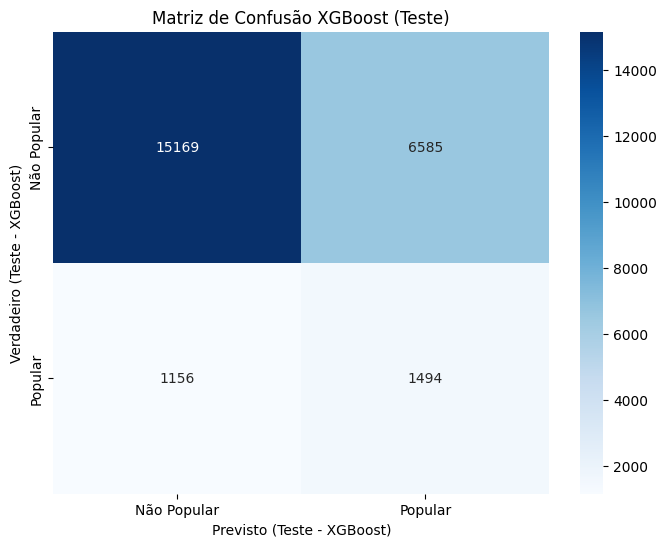


Métricas de Classificação (Teste - XGBoost):
              precision    recall  f1-score   support

 Não Popular       0.93      0.70      0.80     21754
     Popular       0.18      0.56      0.28      2650

    accuracy                           0.68     24404
   macro avg       0.56      0.63      0.54     24404
weighted avg       0.85      0.68      0.74     24404


Matriz de Confusão (Treino com SMOTE - XGBoost):
[[35994 14762]
 [ 8283 42473]]


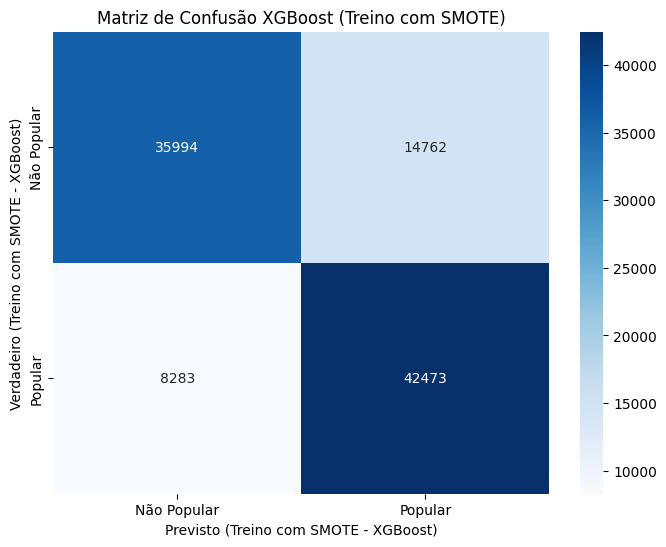


Métricas de Classificação (Treino com SMOTE - XGBoost):
              precision    recall  f1-score   support

 Não Popular       0.81      0.71      0.76     50756
     Popular       0.74      0.84      0.79     50756

    accuracy                           0.77    101512
   macro avg       0.78      0.77      0.77    101512
weighted avg       0.78      0.77      0.77    101512



In [55]:
# Importando as bibliotecas necessárias para XGBoost
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Usando os dados X_train_bal, X_test, y_train_bal, y_test já preparados nas seções anteriores

# Criando e treinando o modelo XGBoost
xgb_model = xgb.XGBClassifier(objective='binary:logistic', # Para classificação binária
                              n_estimators=100,           # Número de árvores
                              learning_rate=0.1,          # Taxa de aprendizado
                              max_depth=5,                # Profundidade máxima da árvore
                              random_state=42,
                              eval_metric='logloss')      # Métrica de avaliação

xgb_model.fit(X_train_bal, y_train_bal)

# Fazendo as previsões no conjunto de teste
y_pred_xgb_test = xgb_model.predict(X_test)

# Calculando e exibindo a matriz de confusão para o conjunto de teste com XGBoost
conf_matrix_xgb_test = confusion_matrix(y_test, y_pred_xgb_test)
print("Matriz de Confusão (Teste - XGBoost):")
print(conf_matrix_xgb_test)

# Plotando a matriz de confusão para o conjunto de teste com XGBoost
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Popular', 'Popular'],
            yticklabels=['Não Popular', 'Popular'])
plt.xlabel('Previsto (Teste - XGBoost)')
plt.ylabel('Verdadeiro (Teste - XGBoost)')
plt.title('Matriz de Confusão XGBoost (Teste)')
plt.show()

# Exibindo as métricas de classificação para o conjunto de teste com XGBoost
print("\nMétricas de Classificação (Teste - XGBoost):")
print(classification_report(y_test, y_pred_xgb_test, target_names=['Não Popular', 'Popular']))

# Fazendo as previsões no conjunto de treino balanceado
y_pred_xgb_train = xgb_model.predict(X_train_bal)

# Calculando e exibindo a matriz de confusão para o conjunto de treino balanceado com XGBoost
conf_matrix_xgb_train = confusion_matrix(y_train_bal, y_pred_xgb_train)
print("\nMatriz de Confusão (Treino com SMOTE - XGBoost):")
print(conf_matrix_xgb_train)

# Plotando a matriz de confusão para o conjunto de treino balanceado com XGBoost
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Popular', 'Popular'],
            yticklabels=['Não Popular', 'Popular'])
plt.xlabel('Previsto (Treino com SMOTE - XGBoost)')
plt.ylabel('Verdadeiro (Treino com SMOTE - XGBoost)')
plt.title('Matriz de Confusão XGBoost (Treino com SMOTE)')
plt.show()

# Exibindo as métricas de classificação para o conjunto de treino balanceado com XGBoost
print("\nMétricas de Classificação (Treino com SMOTE - XGBoost):")
print(classification_report(y_train_bal, y_pred_xgb_train, target_names=['Não Popular', 'Popular']))

# Perfil dos Clusters

Após determinar o número ideal de clusters usando o Método do Cotovelo e Silhueta, podemos agora analisar as características de cada cluster para entender o perfil das músicas dentro de cada grupo.

Número ótimo de clusters sugerido: 8

Perfil médio dos clusters (em features processadas):


,danceability,energy,loudness,speechiness,acousticness,valence,tempo,duration_ms,explicit,liveness,instrumentalness
cluster,,,,,,,,,,,
0,0.758461,0.340533,0.372154,-0.039693,-0.293667,0.972319,-0.090742,-0.153266,-0.305842,-0.263892,-0.475846
1,-0.167679,-1.020824,-0.408886,-0.300252,1.078518,-0.269619,-0.292480,-0.137242,-0.304916,-0.300956,-0.399604
2,-0.280766,0.430639,0.241519,-0.036824,-0.066521,0.121851,0.024297,0.087115,-0.286174,2.705999,-0.295305
3,-0.526650,0.692840,0.600675,-0.062087,-0.742033,-0.379989,0.562281,0.054867,-0.305842,-0.117844,-0.409425
4,-1.242669,-1.809397,-2.426215,-0.325846,1.569660,-1.094330,-0.655006,-0.120063,-0.300042,-0.290871,1.819238
5,0.400293,0.333755,0.416724,0.597489,-0.420993,0.012757,0.055969,-0.249477,3.269666,-0.082861,-0.369009
6,0.189908,0.388145,-0.013086,-0.166826,-0.661663,-0.467545,0.156359,0.713126,-0.304256,-0.277522,1.816146
7,0.042777,0.212398,-0.492184,6.694971,1.279089,-0.108882,-0.743736,-0.101442,1.794119,2.399519,-0.539633


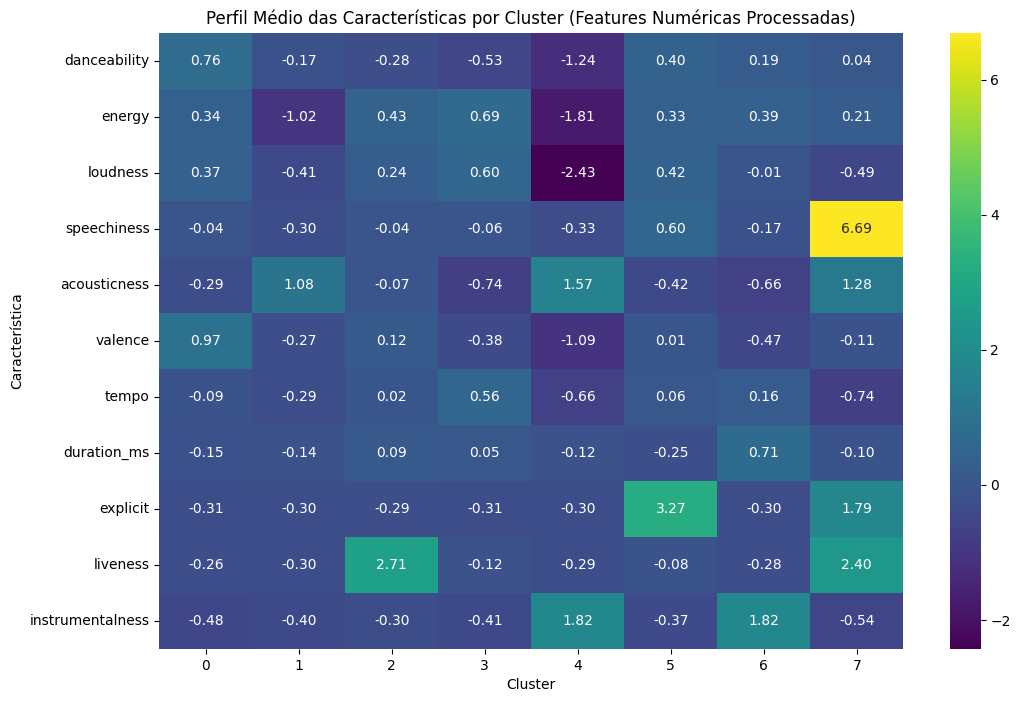

In [42]:
!pip install kneed

# Importar bibliotecas necessárias para K-Means e para definir X e CLUSTER_FEATURES
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from kneed import KneeLocator # Importar KneeLocator
from sklearn.preprocessing import StandardScaler

# Carrega o dataset (usando que dataset_processed.csv é o arquivo correto após o pré-processamento inicial)
df = pd.read_csv("dataset_processed.csv", encoding='utf-8', low_memory=True)

# Definir as colunas numéricas a serem usadas para clustering (CLUSTER_FEATURES)
CLUSTER_FEATURES = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'valence',
    'tempo',
    'duration_ms', # Added duration_ms as it's a numeric feature often used in clustering
    'explicit', # Added explicit as it's a numeric-like feature after scaling
    'liveness', # Added liveness
    'instrumentalness' # Added instrumentalness
]


# Selecionar apenas as CLUSTER_FEATURES para a análise de cluster
df_cluster_data = df[CLUSTER_FEATURES].copy()

# Aplicar StandardScaler nas features de clustering
scaler = StandardScaler()
X = scaler.fit_transform(df_cluster_data)
X = pd.DataFrame(X, columns=CLUSTER_FEATURES) # Convert back to DataFrame


# Método do Cotovelo
sse = {}
# Using a smaller range for k (e.g., 2 to 10) as fitting KMeans to the full dataset
# for many values of k can be computationally expensive.
# If needed, this range can be increased.
for k in range(2, 11):
    try:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        # Fit KMeans on the scaled CLUSTER_FEATURES
        kmeans.fit(X)
        sse[k] = kmeans.inertia_
    except Exception as e:
        print(f"Error fitting KMeans for k={k}: {e}")
        # Break or continue depending on desired behavior
        break


# Verificar se sse não está vazio antes de criar KneeLocator
if sse:
    kneedle = KneeLocator(
        x=list(sse.keys()),
        y=list(sse.values()),
        curve='convex',
        direction='decreasing'
    )
    optimal_k = int(kneedle.elbow) if kneedle.elbow is not None else list(sse.keys())[-1] # Use last k if elbow not found
    print(f"Número ótimo de clusters sugerido: {optimal_k}")

    # Aplicar o K-Means com o número ideal de clusters (optimal_k)
    kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
    clusters = kmeans_final.fit_predict(X) # Fit and predict on scaled CLUSTER_FEATURES

    # Adicionar os rótulos dos clusters ao DataFrame com as features de clustering
    X_clustered = X.copy()
    X_clustered['cluster'] = clusters
    # 'is_popular' não está disponível em dataset_processed.csv, removendo a linha abaixo
    # X_clustered['is_popular'] = y # Add the target variable for analysis

    # Analisar as características médias de cada cluster
    # Group by cluster and calculate the mean of the CLUSTER_FEATURES
    # 'is_popular' is not available, so removed from cols_for_profile and groupby
    cols_for_profile = CLUSTER_FEATURES
    cluster_profile = X_clustered.groupby('cluster')[cols_for_profile].mean()


    print("\nPerfil médio dos clusters (em features processadas):")
    display(cluster_profile)

    # Análise de popularidade por cluster não será possível sem a coluna 'is_popular'
    # Remover as linhas relacionadas à análise e visualização de popularidade por cluster
    # popularity_by_cluster = X_clustered.groupby('cluster')['is_popular'].value_counts(normalize=True).unstack().fillna(0)
    # print("\nDistribuição de Popularidade (proporção) por Cluster:")
    # display(popularity_by_cluster)
    # popularity_by_cluster.plot(kind='bar', stacked=True, figsize=(10, 7), cmap='viridis')
    # plt.title('Proporção de Músicas Populares vs Não Populares por Cluster')
    # plt.xlabel('Cluster')
    # plt.ylabel('Proporção')
    # plt.xticks(rotation=0)
    # plt.legend(title='É Popular', labels=['Não Popular', 'Popular'])
    # plt.tight_layout()
    # plt.show()


    # Optional: Visualize mean feature values by cluster using a heatmap
    plt.figure(figsize=(12, 8))
    # Ensure the heatmap uses the cluster_profile with only the relevant features
    sns.heatmap(cluster_profile.T, annot=True, cmap='viridis', fmt='.2f')
    plt.title('Perfil Médio das Características por Cluster (Features Numéricas Processadas)') # Updated title
    plt.xlabel('Cluster')
    plt.ylabel('Característica')
    plt.show()

else:
    print("Não foi possível calcular o Método do Cotovelo. Verifique se os dados e o range de clusters são apropriados.")

# Análise Exploratória de Dados (EDA)

Nesta seção, exploraremos as distribuições e características individuais das variáveis presentes no conjunto de dados.

## EDA de Variáveis Numéricas

Análise visual e estatística das variáveis numéricas.

In [25]:
# Estatísticas descritivas para variáveis numéricas
print("Estatísticas Descritivas para Variáveis Numéricas:")
display(df.describe())

Estatísticas Descritivas para Variáveis Numéricas:


,duration_ms,explicit,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,...,key_8,key_9,key_10,key_11,mode_1,time_signature_1,time_signature_3,time_signature_4,time_signature_5,is_popular
count,8.134400e+04,8.134400e+04,8.134400e+04,8.134400e+04,8.134400e+04,8.134400e+04,8.134400e+04,8.134400e+04,8.134400e+04,8.134400e+04,...,81344.000000,81344.000000,81344.000000,81344.000000,81344.000000,81344.000000,81344.000000,81344.00000,81344.000000,81344.000000
mean,6.708507e-17,6.568747e-17,3.074733e-17,-4.556195e-16,3.144613e-17,-1.649175e-16,-2.431834e-16,5.590423e-18,-2.138337e-16,8.665155e-17,...,0.060939,0.101101,0.065364,0.079539,0.632339,0.009527,0.085366,0.88497,0.018293,0.108601
std,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,...,0.239219,0.301465,0.247169,0.270579,0.482171,0.097143,0.279427,0.31906,0.134009,0.311139
min,-1.986473e+00,-3.058416e-01,-3.146511e+00,-2.455267e+00,-7.717083e+00,-7.630481e-01,-9.697352e-01,-5.571080e-01,-1.108192e+00,-1.758970e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,-4.939377e-01,-3.058416e-01,-6.372909e-01,-6.960494e-01,-3.501232e-01,-4.535155e-01,-9.229648e-01,-5.571080e-01,-6.113948e-01,-8.439478e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000
50%,-1.391289e-01,-3.058416e-01,7.721789e-02,1.661606e-01,2.510853e-01,-3.420495e-01,-4.108441e-01,-5.568405e-01,-4.373896e-01,-5.421899e-02,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.00000,0.000000,0.000000
75%,3.084659e-01,-3.058416e-01,7.354662e-01,8.582484e-01,6.511055e-01,-1.708309e-02,8.804883e-01,-9.569346e-02,3.191546e-01,8.076485e-01,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.00000,0.000000,0.000000
max,4.297126e+01,3.269666e+00,2.395152e+00,1.411145e+00,2.474383e+00,7.511161e+00,1.960030e+00,2.458674e+00,3.935436e+00,2.018819e+00,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000


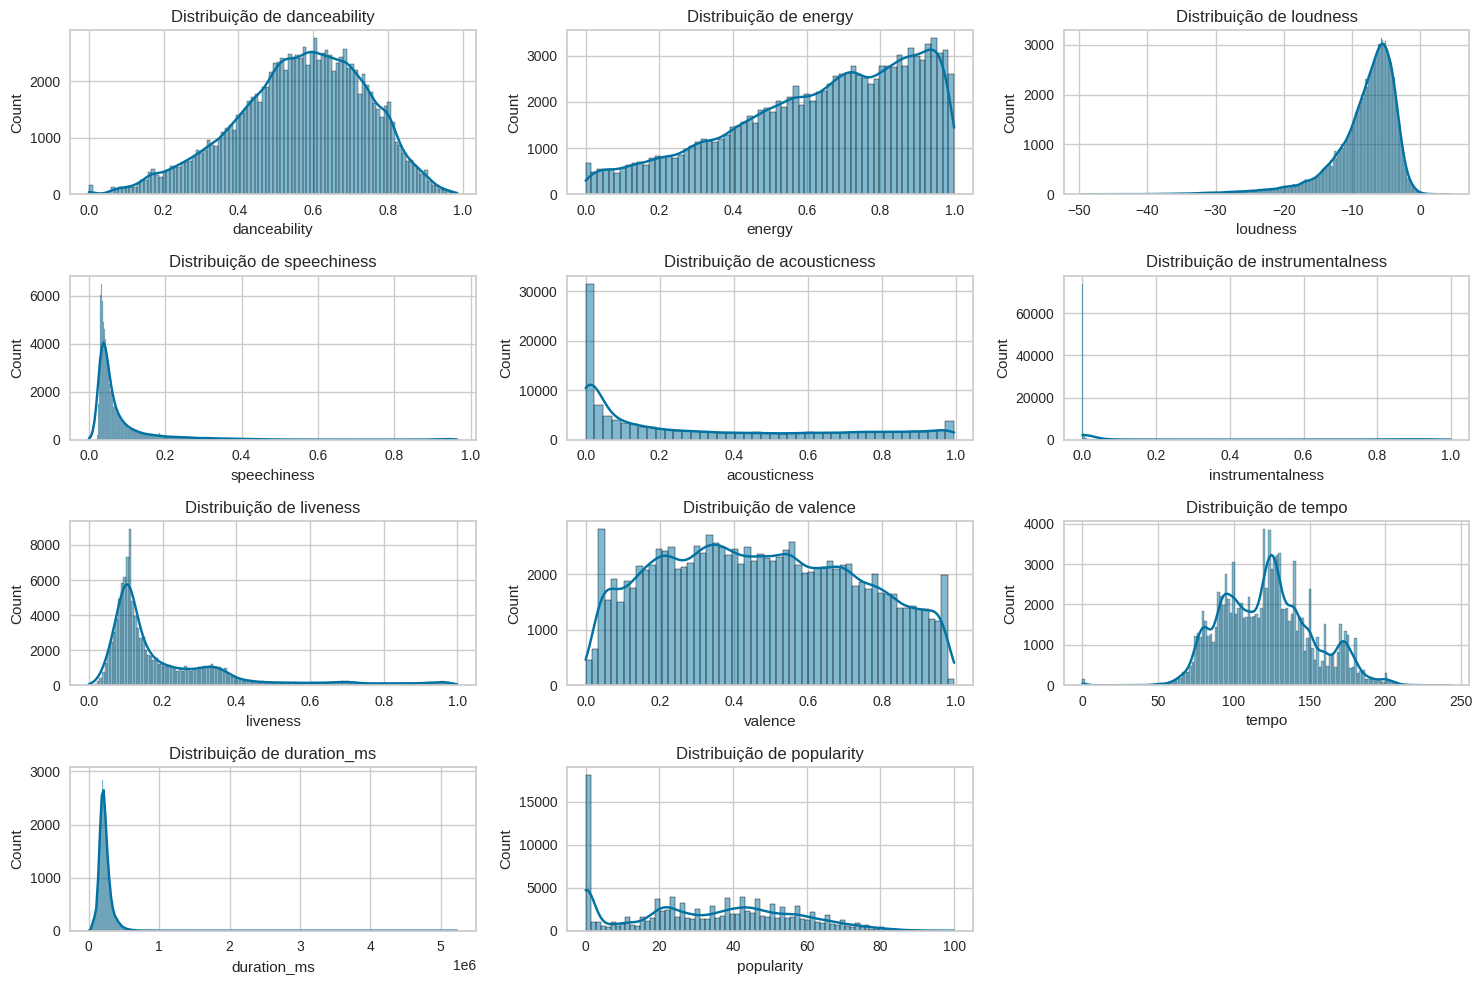

In [ ]:
# Histograma com Curva de Densidade (KDE) para variáveis numéricas selecionadas
numeric_cols = ['danceability', 'energy', 'loudness', 'speechiness',
                'acousticness', 'instrumentalness', 'liveness', 'valence',
                'tempo', 'duration_ms', 'popularity']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribuição de {col}')
plt.tight_layout()
plt.show()

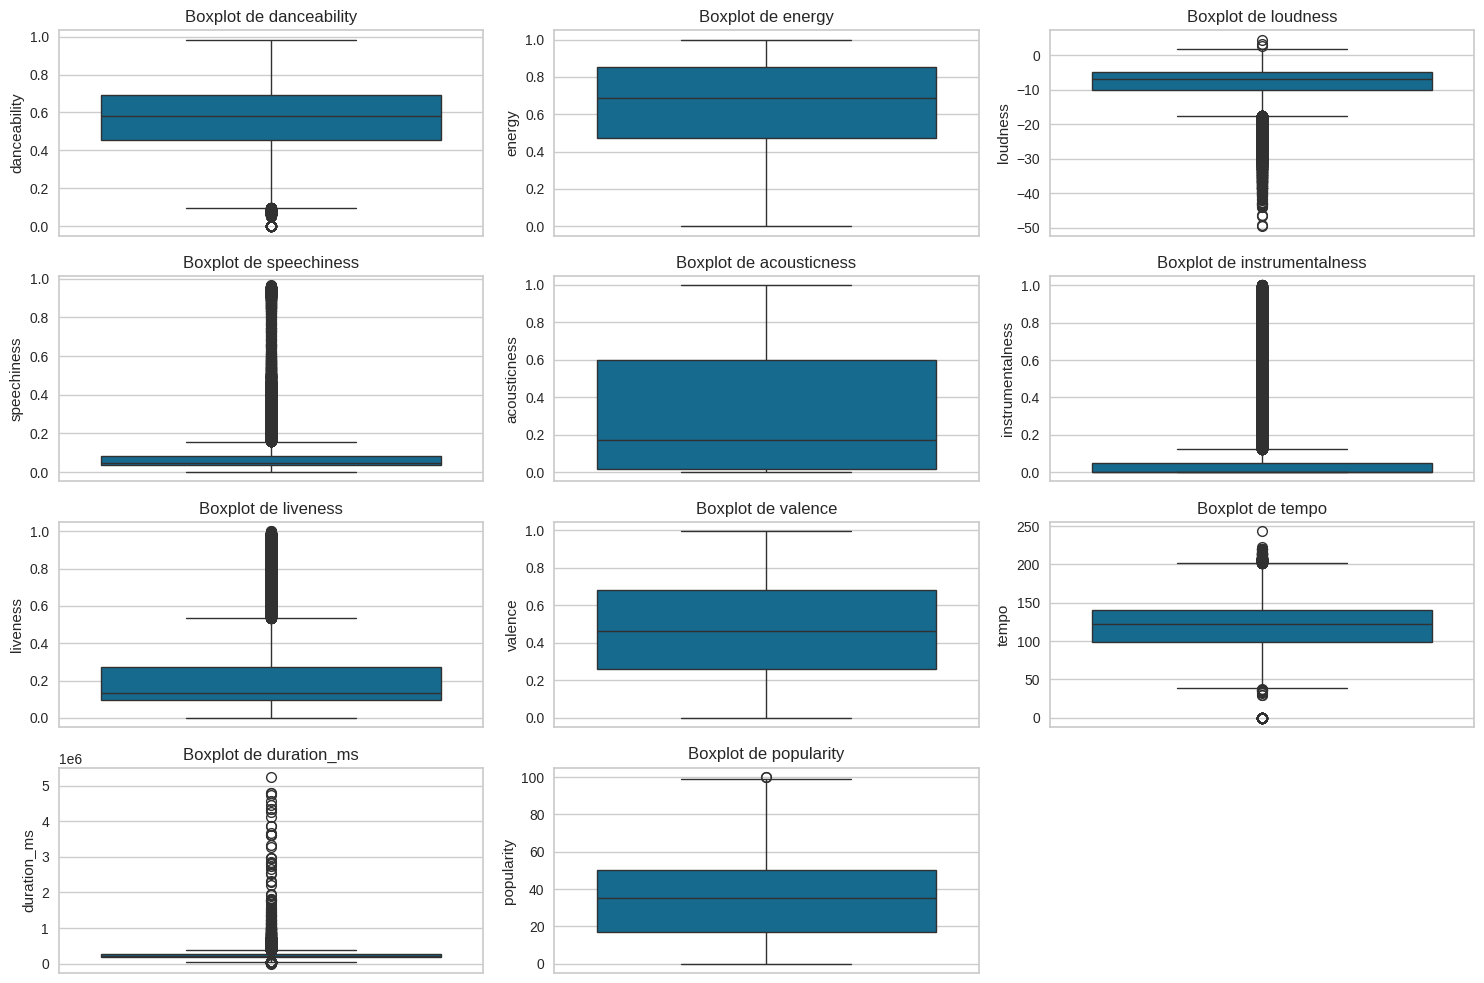

In [ ]:
# Boxplots para variáveis numéricas selecionadas para identificar outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

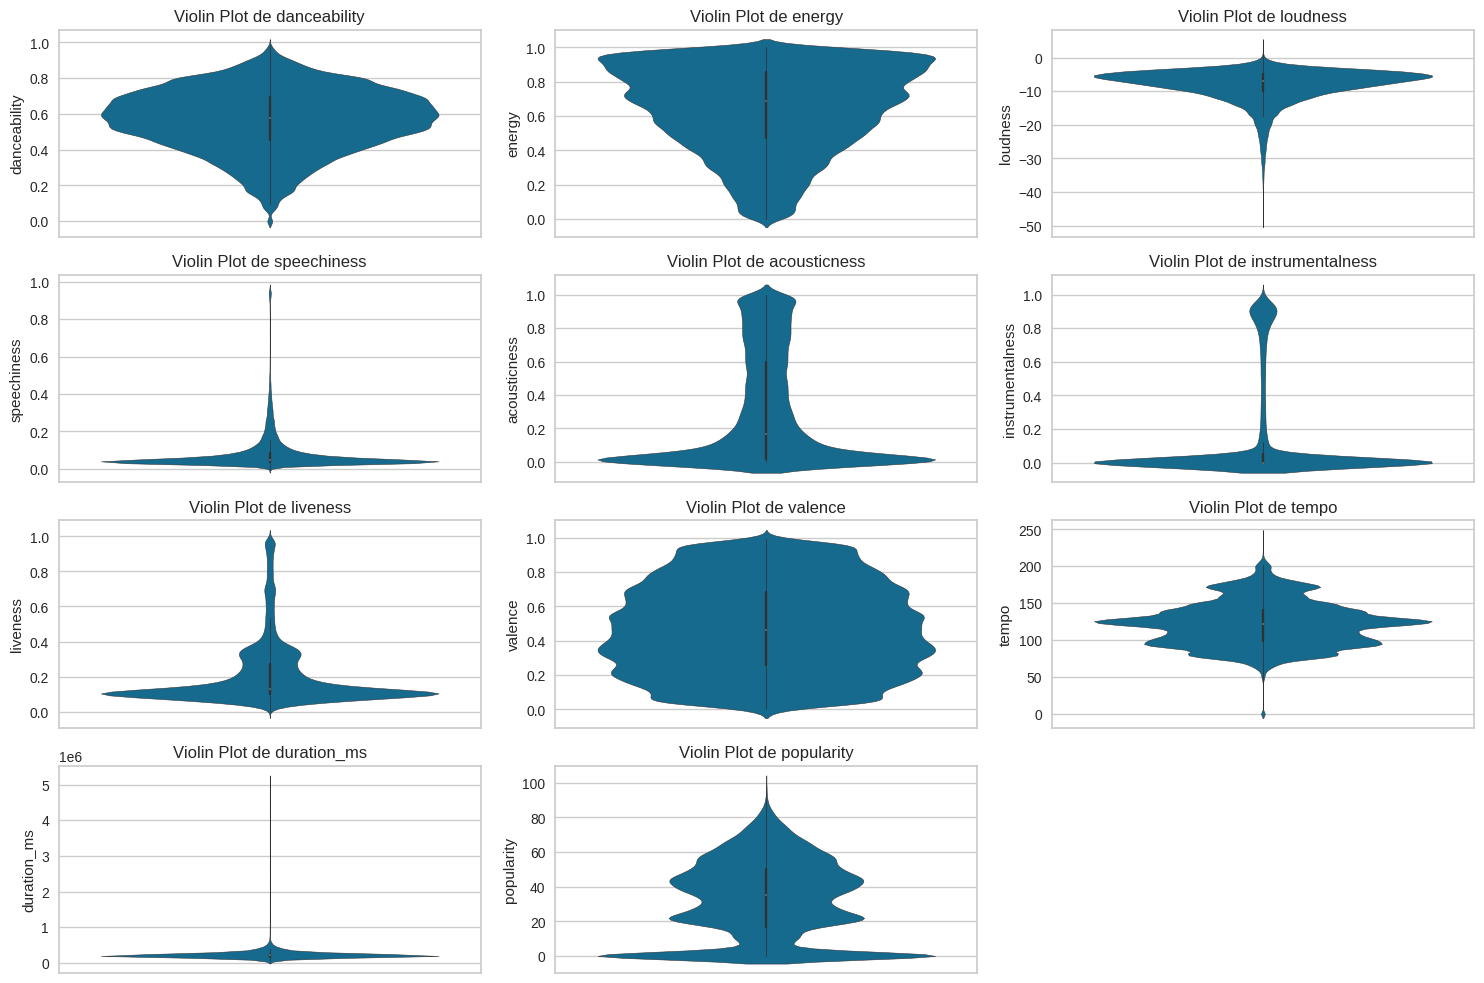

In [ ]:
# Violin Plots para variáveis numéricas selecionadas
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 3, i + 1)
    sns.violinplot(y=df[col])
    plt.title(f'Violin Plot de {col}')
plt.tight_layout()
plt.show()

## EDA de Variáveis Categóricas

Análise visual das distribuições de frequência das variáveis categóricas.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carrega o dataset original para garantir que as colunas 'track_name' e 'artists' estejam presentes
try:
    df = pd.read_csv("dataset.csv", encoding='utf-8', low_memory=True)

    # Remove coluna de índice automática, se existir
    df = df.drop(columns=['Unnamed: 0'], errors='ignore')

    # Mantém apenas a primeira linha de cada track_id (uma linha por música)
    df_amostrado = df.drop_duplicates(subset=['track_name', 'artists'], keep='first')


    # Gráficos de barras para variáveis categóricas
    categorical_cols = ['explicit', 'key', 'mode', 'time_signature', 'track_genre']

    plt.figure(figsize=(18, 15))
    for i, col in enumerate(categorical_cols):
        plt.subplot(3, 2, i + 1)
        # Use df_amostrado which contains the original categorical columns
        sns.countplot(y=df_amostrado[col], order=df_amostrado[col].value_counts().index)
        plt.title(f'Distribuição de {col}')
        plt.xlabel('Contagem')
        plt.ylabel(col)
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("Erro: 'dataset.csv' não encontrado. Por favor, verifique se o arquivo está no diretório correto.")
    print("Alternatively, if your processed file contains the necessary columns, please update the filename.")

Erro: 'dataset.csv' não encontrado. Por favor, verifique se o arquivo está no diretório correto.
Alternatively, if your processed file contains the necessary columns, please update the filename.


*Observação: Treemaps para 'track_genre' podem ser muito densos devido ao grande número de categorias. O gráfico de barras já mostra a distribuição.*

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

## Análise Bivariada e Multivariada

Exploração das relações entre pares de variáveis e identificação de padrões mais complexos.

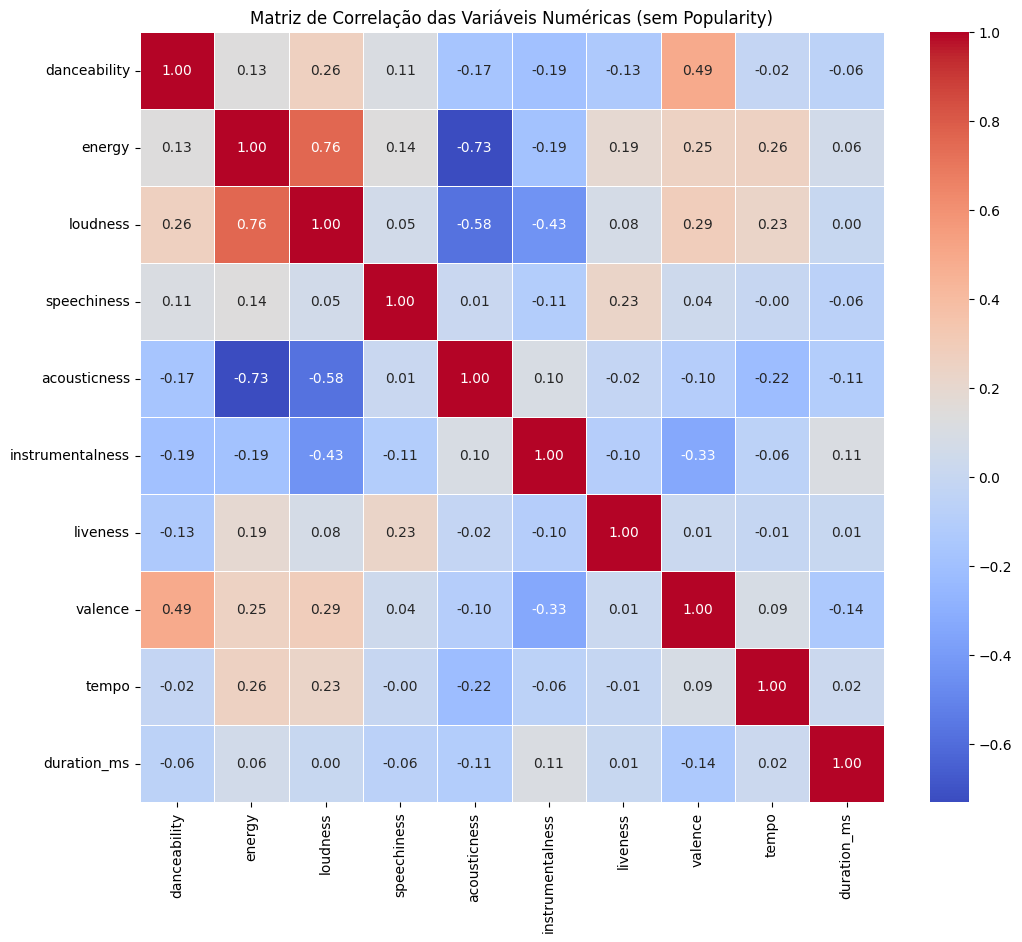

In [37]:
# Carrega o dataset (usando o nome de arquivo fornecido)
df = pd.read_csv("dataset_processed.csv", encoding='utf-8', low_memory=True)

# Remove coluna de índice automática, se existir
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# NOTA: 'track_name' e 'artists' não estão em dataset_processed.csv.
# Removendo a linha que tenta remover duplicatas com base nessas colunas.
# Se a remoção de duplicatas for necessária para esta análise,
# considere usar 'track_id' (se disponível e único) ou o dataset original.
# df_amostrado = df.drop_duplicates(subset=['track_name', 'artists'], keep='first')
# Usaremos o df processado diretamente para a matriz de correlação das colunas numéricas presentes.
df_amostrado = df.copy() # Usar o df carregado como base para a seleção de colunas

# Calcular a matriz de correlação para variáveis numéricas
# Removendo 'popularity' da lista, pois não está presente em dataset_processed.csv
numeric_cols = ['danceability', 'energy', 'loudness', 'speechiness',
                'acousticness', 'instrumentalness', 'liveness', 'valence',
                'tempo', 'duration_ms'] # Removed 'popularity'


# Garantir que apenas as colunas numéricas existam no DataFrame antes de calcular a correlação
# Use df_amostrado which still contains the other numeric columns
numeric_df = df_amostrado[numeric_cols].copy()

correlation_matrix = numeric_df.corr()

# Visualizar a matriz de correlação usando um heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação das Variáveis Numéricas (sem Popularity)')
plt.show()

In [ ]:
import pandas as pd

# Carrega o dataset (assumindo que o arquivo se chama 'dataset_processed.csv')
try:
    df = pd.read_csv('dataset_processed.csv')
    print("Dataset carregado com sucesso.")
except FileNotFoundError:
    print("Erro: 'dataset_processed.csv' não encontrado. Por favor, verifique se o arquivo está no diretório correto.")
    # Você pode querer carregar seu dataset real aqui se o nome for diferente
    # df = pd.read_csv('nome_do_seu_dataset.csv')

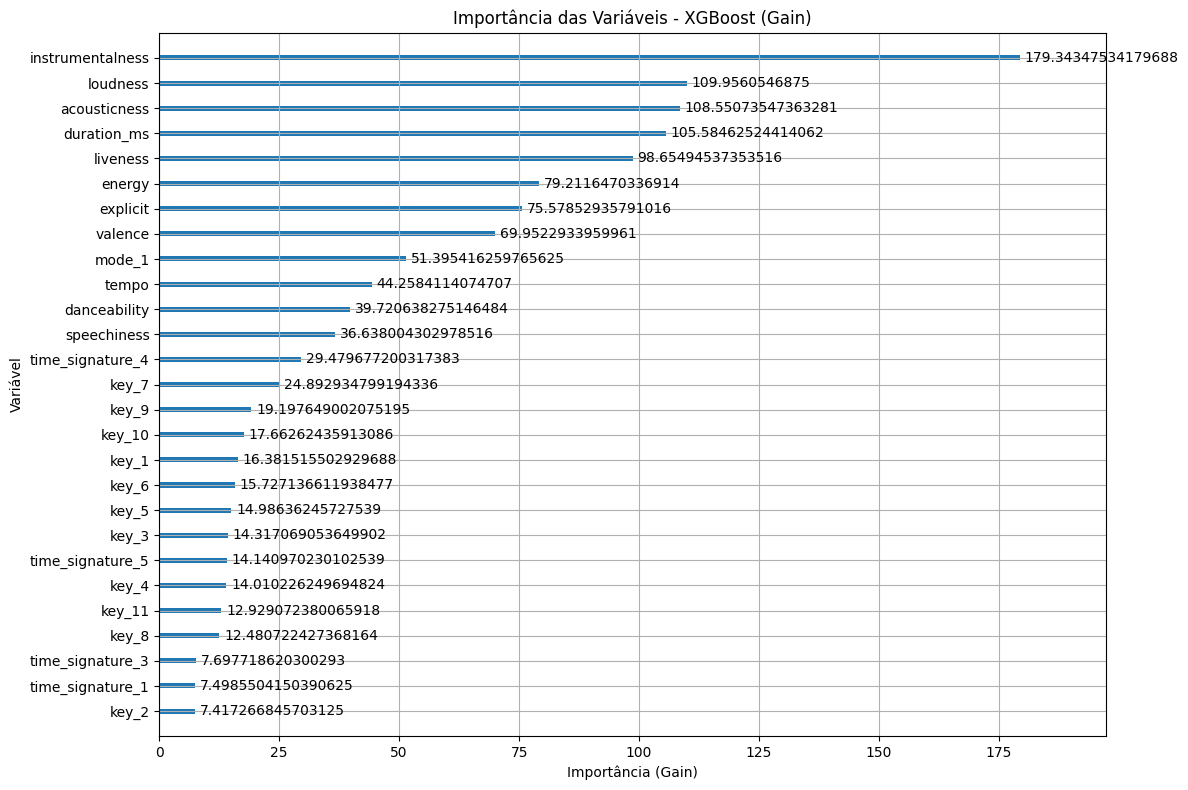

In [54]:
# Analisar a importância das features para o modelo XGBoost

# Usar a função plot_importance do XGBoost para visualizar a importância das features
# Vamos usar 'gain' para ver a contribuição média para a melhoria do modelo
plt.figure(figsize=(12, 8))
xgb.plot_importance(xgb_model, importance_type='gain', ax=plt.gca())
plt.title('Importância das Variáveis - XGBoost (Gain)')
plt.xlabel('Importância (Gain)')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

In [57]:
# Comparar o desempenho dos modelos Random Forest, SVM e XGBoost no conjunto de teste

# Assumindo que X e y estão definidos a partir das células de pré-processamento

# Dividir em conjuntos de treino e teste (duplicado para garantir que os dados estejam prontos nesta célula)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y # Mantém proporção das classes
)

# Aplicar SMOTE para balancear as classes no conjunto de treino (duplicado)
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# --- Treinamento dos Modelos ---

# 1. Random Forest com SMOTE (copiado da célula qdwRYDGHVUFh)
from sklearn.ensemble import RandomForestClassifier
model_smote = RandomForestClassifier(n_estimators=100, random_state=42)
model_smote.fit(X_train_bal, y_train_bal)
y_pred_rf_test = model_smote.predict(X_test)


# 2. SVM (copiado da célula qxzPOiYoeOCI)
from sklearn.svm import SVC
svm_model = SVC(kernel='linear', random_state=42, probability=True) # Added probability=True for consistency if needed later
svm_model.fit(X_train, y_train) # Train SVM on original imbalanced data as in cell qxzPOiYoeOCI
y_pred_svm_test = svm_model.predict(X_test)


# 3. XGBoost (copiado da célula 55baf39b - usando XGBClassifier API)
import xgboost as xgb
xgb_model = xgb.XGBClassifier(objective='binary:logistic',
                              n_estimators=100,
                              learning_rate=0.1,
                              max_depth=5,
                              random_state=42,
                              use_label_encoder=False,
                              eval_metric='logloss')
xgb_model.fit(X_train_bal, y_train_bal) # Train XGBoost on balanced data
y_pred_xgb_test = xgb_model.predict(X_test) # Predictions are already binary with this setup


# --- Comparação de Desempenho ---
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Ensure seaborn is imported


# Obter relatórios de classificação para o conjunto de teste
report_rf = classification_report(y_test, y_pred_rf_test, target_names=['Não Popular', 'Popular'], output_dict=True)
report_svm = classification_report(y_test, y_pred_svm_test, target_names=['Não Popular', 'Popular'], output_dict=True)
report_xgb = classification_report(y_test, y_pred_xgb_test, target_names=['Não Popular', 'Popular'], output_dict=True)


# Extrair métricas importantes para comparação
comparison_data = {
    'Modelo': ['Random Forest (com SMOTE)', 'SVM (sem SMOTE no treino)', 'XGBoost (com SMOTE)'],
    'Acurácia (Teste)': [report_rf['accuracy'], report_svm['accuracy'], report_xgb['accuracy']],
    'Precisão (Popular)': [report_rf['Popular']['precision'], report_svm['Popular']['precision'], report_xgb['Popular']['precision']],
    'Recall (Popular)': [report_rf['Popular']['recall'], report_svm['Popular']['recall'], report_xgb['Popular']['recall']],
    'F1-score (Popular)': [report_rf['Popular']['f1-score'], report_svm['Popular']['f1-score'], report_xgb['Popular']['f1-score']]
}

comparison_df = pd.DataFrame(comparison_data)

# Exibir a tabela de comparação
print("Comparação do Desempenho dos Modelos no Conjunto de Teste:")
display(comparison_df)

# Optional: Display confusion matrices for comparison as well
# print("\nMatrizes de Confusão no Conjunto de Teste:")

# plt.figure(figsize=(18, 5)) # Adjust size as needed

# plt.subplot(1, 3, 1)
# sns.heatmap(confusion_matrix(y_test, y_pred_rf_test), annot=True, fmt='d', cmap='Blues', xticklabels=['Não Popular', 'Popular'], yticklabels=['Não Popular', 'Popular'])
# plt.title('RF com SMOTE')
# plt.xlabel('Previsto'); plt.ylabel('Verdadeiro')

# plt.subplot(1, 3, 2)
# sns.heatmap(confusion_matrix(y_test, y_pred_svm_test), annot=True, fmt='d', cmap='Blues', xticklabels=['Não Popular', 'Popular'], yticklabels=['Não Popular', 'Popular'])
# plt.title('SVM')
# plt.xlabel('Previsto'); plt.ylabel('Verdadeiro')

# plt.subplot(1, 3, 3)
# sns.heatmap(confusion_matrix(y_test, y_pred_xgb_test), annot=True, fmt='d', cmap='Blues', xticklabels=['Não Popular', 'Popular'], yticklabels=['Não Popular', 'Popular'])
# plt.title('XGBoost com SMOTE')
# plt.xlabel('Previsto'); plt.ylabel('Verdadeiro')

# plt.tight_layout()
# plt.show()

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:58:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Comparação do Desempenho dos Modelos no Conjunto de Teste:


,Modelo,Acurácia (Teste),Precisão (Popular),Recall (Popular),F1-score (Popular)
0,Random Forest (com SMOTE),0.806097,0.218649,0.305283,0.254803
1,SVM (sem SMOTE no treino),0.891411,0.000000,0.000000,0.000000
2,XGBoost (com SMOTE),0.682798,0.184924,0.563774,0.278498
